In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [14]:
from catrace.run.run_average_timecourse import run_average_timecourse, RunAverageTimecourseParams


## Dp

Extracted_Data_mock1_Fish1 None
Extracted_Data_mock4_FishX None
Extracted_Data_mock5_FishX None
Extracted_Data_mock6_FishX None
Extracted_Data_mock8_FishY None
Extracted_Data_mockA10_FishX None
Extracted_Data_mockA10_FishY None
Extracted_Data_mockA10_fishZ None
Extracted_Data_Exp4_Fish3 None
Extracted_Data_Exp6_Fish1 None
Extracted_Data_Exp6_Fish4 None
Extracted_Data_Exp7_Fish3 None
Extracted_Data_Exp8_Fish1 None
Extracted_Data_Exp8_Fish4 None
Extracted_Data_ExpA10_Setup2_Fish1 None
Extracted_Data_ExpA10_Setup2_Fish2 None
Extracted_Data_ExpA10_Setup3_Fish1 None


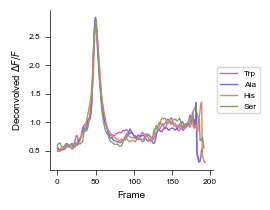

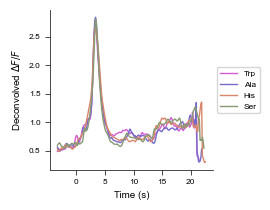

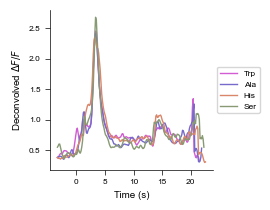

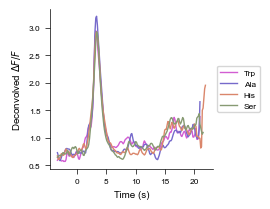

In [15]:
params = RunAverageTimecourseParams(
    config_file = '../dataset_configs/adult_dataset_t7.json',
    assembly_name = '',
    do_plot_per_fish = False,
    #dff = dff,
    figsize=(2.8, 2.2),
    cut_time=3.3,
    odor_colors = ['#d25dd2', '#766acb', '#da866b', '#879A73'], #'#daa36b'],
    alpha = 0.7,
    convert_to_rate=True,
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

dff, outfigs, odor_avg_naive_time, odor_avg_trained_time  = run_average_timecourse(params)

In [16]:
import numpy as np
frame_rate=7.5
for name in ['fig_time', 'fig_naive_time', 'fig_trained_time']:
    fig = outfigs[name]
    ax = fig.get_axes()[0]
    ax.set_xlim([0, 16])
    ax.set_ylim(np.array([0.005, 0.06])*frame_rate)
    # Set xticks with interval of 2.5 using multiplelocator
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))

    ax.set_ylabel('Firing rate (Hz)')#'Spike probability')

    if ax.get_legend():
        ax.get_legend().remove()

    # Set figure size
    fig.set_size_inches(2.3, 1.55)
    fig.tight_layout()


from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '../../figures_for_paper'
dataset_name = 'BNP'
save_figure_for_paper(outfigs['fig_time'], f'{dataset_name}_timecourse', paper_fig_dir)
save_figure_for_paper(outfigs['fig_naive_time'], f'{dataset_name}_timecourse_naive', paper_fig_dir)
save_figure_for_paper(outfigs['fig_trained_time'], f'{dataset_name}_timecourse_trained', paper_fig_dir)

In [17]:
# Save the average timecourse data to a CSV file
import os
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure09')
os.makedirs(save_dir, exist_ok=True)

# Only take time points between 0 and 16 seconds
odor_avg_naive_time_short = odor_avg_naive_time[(odor_avg_naive_time['time'] >= 0) & (odor_avg_naive_time['time'] <= 16)]
odor_avg_trained_time_short = odor_avg_trained_time[(odor_avg_trained_time['time'] >= 0) & (odor_avg_trained_time['time'] <= 16)]

odor_avg_naive_time_short.to_csv(os.path.join(save_dir, f'extended_figure09a_adult_average_traces_naive.csv'))
odor_avg_trained_time_short.to_csv(os.path.join(save_dir, f'extended_figure09a_adult_average_traces_trained.csv'))